#### Groupes : Marwane / Alassane / Nathan

In [1278]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
np.random.seed(0)

In [1280]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev = prev[["type_sol", "diametre", "hauteur", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [1282]:
x = arbres[["type_sol", "diametre", "hauteur", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()
y = arbres[["classification_diagnostic"]]

# Naïve Bayes

## Analyse & Visualisation Données

In [1286]:
display(x.head(2))
display(y.head())

,type_sol,diametre,hauteur,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,,,
0,MA,31.830989,500,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,76.394373,800,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0


,classification_diagnostic
ID_ARBRE,
0,C1
1,C4
2,C1
3,C2
4,C2


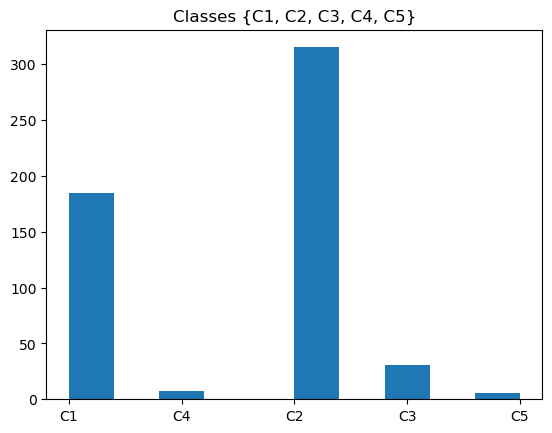

Proportions respectives par classe : 
[0.34007353 0.57904412 0.05698529 0.01286765 0.01102941]


In [1288]:
plt.hist(y)
plt.title('Classes {C1, C2, C3, C4, C5}')
plt.show()

unique, counts = np.unique(y, return_counts = True)
print("Proportions respectives par classe : ")
print(counts/len(y))

In [1289]:
def corr(x, y):
    x, y = np.array(x), np.array(y)
    mx, my = np.mean(x), np.mean(y)
    return np.sum((x-mx)*(y-my)) / (np.sqrt(np.sum((x-mx)**2)) * np.sqrt(np.sum((y-my)**2)))

corr(x['diametre'], x['hauteur'])

0.6821820682130718

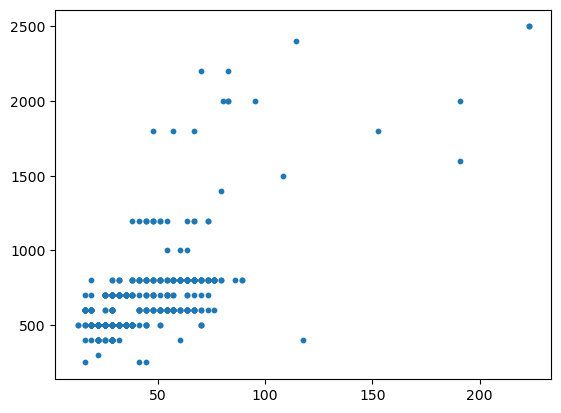

In [1292]:
plt.scatter(x["diametre"], x["hauteur"], s=10)

(array([391.,   0.,   0., 110.,   0.,   0.,  39.,   0.,   0.,   4.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

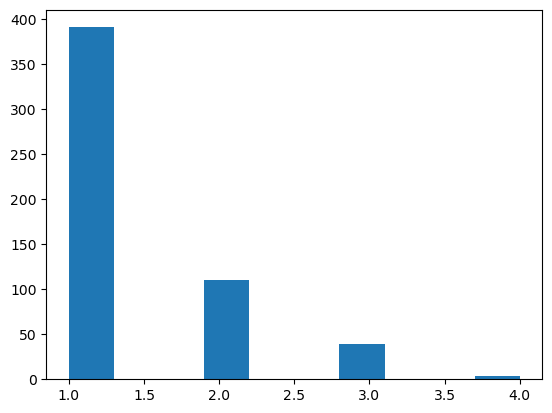

In [1294]:
plt.hist(x["esperance_maintien"])

### Train_test_split 

In [1297]:
from sklearn.model_selection import train_test_split

In [1299]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

## Entraînement - Calculs Probas - Classifieur de Bayes

In [1302]:
def log_proba_xsy(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)

    log_pxsy = []
    for c in y_unique:
        log_prob_c = 0 #Log probabilité de la classe Y=c
        for col, x_val in zip(x_colonnes, tab_val):
            num = np.sum((X[col] == x_val) & (Y["classification_diagnostic"] == c)) + 1  # Lissage de Laplace
            denom = np.sum(Y["classification_diagnostic"] == c) + len(np.unique(X[col])) 
            log_prob_c = log_prob_c + np.log(num / denom)  # Ajout du log de la probabilité conditionnelle
        log_pxsy.append(log_prob_c)
    return np.array(log_pxsy)

print(log_proba_xsy(x, x.iloc[0], y))

[ -8.02315196 -10.93974208 -14.60792874 -20.39423833 -23.27582546]


In [1303]:
def proba_y(Y):
    y_unique = np.unique(Y)
    return [np.sum(Y["classification_diagnostic"]==c)/len(Y) for c in y_unique]

In [1306]:
def log_proba_y(Y):
    y_unique, counts = np.unique(Y, return_counts=True)
    return np.log(counts / len(Y))

print(log_proba_y(y))

[-1.07859342 -0.54637661 -2.86496204 -4.3530391  -4.50718978]


In [1308]:
def classifieur(X, tab_val, Y):
    y_unique = np.unique(Y)
    log_p_y = log_proba_y(Y)
    log_pxsy = log_proba_xsy(X, tab_val, Y)
    probas_ysx = log_pxsy + log_p_y
    
    return y_unique[np.argmax(probas_ysx)]

In [1310]:
test_prediction = np.array([classifieur(X_train, X_test.iloc[i], Y_train) for i in range(len(X_test))])
test_prediction

array(['C2', 'C1', 'C1', 'C1', 'C3', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C1', 'C1',
       'C1', 'C1', 'C2', 'C2', 'C2', 'C3', 'C2', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C4', 'C1', 'C3', 'C1',
       'C2', 'C3', 'C1', 'C2', 'C2', 'C1', 'C2', 'C1', 'C1', 'C3', 'C1',
       'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C3', 'C2', 'C3', 'C2', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1',
       'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2'],
      dtype='<U2')

### Accuracy et Taux d'erreur

In [1312]:
def taux_erreur(predict, y):
    erreurs = len([i for i, j in zip(predict, y.to_numpy()) if i != j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Taux d'erreur : {taux}%")

In [1313]:
taux_erreur(test_prediction, Y_test)

Taux d'erreur : 29.3578%


In [1314]:
def are(predict, Y):
    erreurs = len([i for i, j in zip(predict, Y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(Y)) * 100, 5)
    #print(f"Average Classification Accuracy : {taux}%")
    return taux

In [1315]:
are(test_prediction, Y_test)

70.6422

### Matrice de Confusion

In [1322]:
def matrice_confusion(prediction, reality):
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y ("reality").
    stack_predict_et_y = np.vstack((prediction, reality["classification_diagnostic"])).T
    classes_y = np.unique(reality)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    return confusion_matrix

matrice_confusion(test_prediction, Y_test)

array([[40,  6,  0,  0,  0],
       [16, 34,  4,  0,  0],
       [ 1,  2,  2,  0,  0],
       [ 1,  0,  1,  1,  0],
       [ 1,  0,  0,  0,  0]])

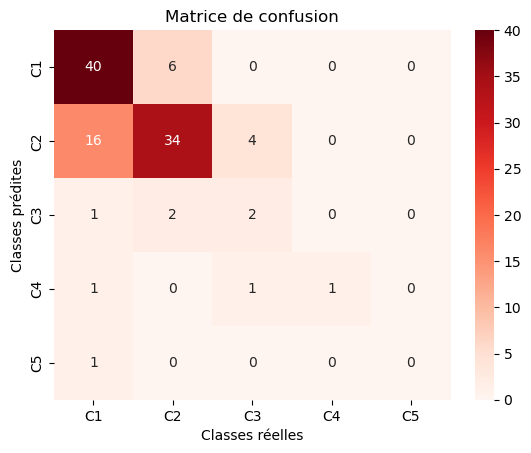

In [1324]:
sns.heatmap(matrice_confusion(test_prediction, Y_test), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

### Prédictions sur le dataset "Prev"

In [1327]:
prev_prediction = np.array([classifieur(X_train, prev.iloc[i], Y_train) for i in range(len(prev))])
prev_prediction

array(['C2', 'C2', 'C2', 'C1', 'C3', 'C1', 'C1', 'C1', 'C1', 'C2', 'C5',
       'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C3', 'C2', 'C3',
       'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C5', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2',
       'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C1',
       'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C1', 'C3', 'C1', 'C2', 'C1', 'C1', 'C1', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2',
       'C1', 'C2', 'C2', 'C3', 'C2', 'C1', 'C2', 'C5', 'C2', 'C2', 'C1',
       'C2', 'C2', 'C1', 'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C1', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C1', 'C1'], dtype='<U2')

### Indexage et sauvegarde du ficher .csv

In [158]:
sub = pd.DataFrame({'classification_diagnostic': prev_prediction})
sub.index.name = "ID_ARBRE"
id_arbre = prev.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [160]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3


In [1349]:
sub.to_csv("prevision_naive_bayes.csv")

# KNN

### Fonction des Distances

In [1330]:
# La fonction prend deux NP arrays de taille identiques
def distance_euclidienne(v1, v2):
    return np.sqrt(np.sum((v1 - v2)**2))

distance_euclidienne(np.array([2, 2]), np.array([1, 7]))

5.0990195135927845

In [1331]:
# La fonction prend deux NP arrays de même taille
def distance_manhattan(v1, v2):
    return np.sum(np.abs((v1 - v2)))

### Encodage des données Arbres 
#### On a encodé a précisé manuellement l'ordre de l'encodage des variables en fonction de leur signification pour que la fonction OrdinalEncoder de Scikit Learn puisse numériser nos données avec l'ordre qu'on lui a donné (Cela évite qu'il encode automatiquement les variables et éviter qu'il encode les valeur juste en fonction de l'ordre alphabétique et fausser notre jeu d'entraînement)

In [1333]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [1334]:
x = arbres[["type_sol", "diametre", "hauteur", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()
y = arbres[["classification_diagnostic"]]

In [1335]:
nominales_features = ["type_sol", "port_arbre"]

arbres_ordinales = {
    'classe_age' : ['J', 'JA', 'A', 'AM'],
    'classe_hauteur' : ['H1', 'H2', 'H3', 'H4', 'H5'],
    'classe_circonference' : ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7'],
    'vigueur_pousse' : ['D', 'P', 'MP', 'PP'],
    'plaie_collet' : ['AU', 'RCPPL', 'RCPLS', 'RCPLC', 'RCPLCF', 'RCPLNC', 'RCPLNS'],
    'fissure_tronc' : ['TFF', 'TFO', 'TPF'],
    'plaie_tronc' : ['ZZ', 'TPPL', 'TPLS', 'TPLC', 'TPLCF', 'TPLNC'],
    'fissure_houppier' : ['HFF ', 'HFO ', 'HPF '],
    'bois_mort_houppier' : ['HBMI ', 'HBMU ', 'HPBM '],
    'plaie_houppier' : ['ZZ', 'HPPL', 'HPLS', 'HPLC', 'HPLNC']
}

# Boucle pour appliquer l'ordinal encoding selon l'ordre défini
for col, order in arbres_ordinales.items():
    if col in x.columns:
        mapping = {cat: i for i, cat in enumerate(order)}
        x[col] = x[col].map(mapping)

In [1342]:
preprocesseur = ColumnTransformer(
    transformers = [
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominales_features)],
    remainder = "passthrough"
)

x_encode = preprocesseur.fit_transform(x)
colonnes = preprocesseur.get_feature_names_out()
x_encode = pd.DataFrame(x_encode, columns = colonnes)

x_encode = x_encode.drop("ohe__type_sol_TV", axis=1)
# On a retiré la variable "ohe__type_sol_TV" car elle n'apparaît pas dans le jeu de données du dataset à prédire "prev"

### Encodage des données Prev

In [1345]:
prev2 = prev[["type_sol", "diametre", "hauteur", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()

In [1347]:
nominales_features = ["type_sol", "port_arbre"]

prev_ordinales = {
    'classe_age' : ['J', 'JA', 'A'],
    'classe_hauteur' : ['H1', 'H2', 'H3', 'H4'],
    'classe_circonference' : ['C1', 'C2', 'C3', 'C4'],
    'vigueur_pousse' : ['P', 'MP', 'PP'],
    'plaie_collet' : ['RCPPL', 'RCPLS', 'RCPLC', 'RCPLNC'],
    'fissure_tronc' : ['TFF', 'TPF'],
    'plaie_tronc' : ['TPPL', 'TPLS', 'TPLC', 'TPLNC'],
    'fissure_houppier' : ['HFF ', 'HPF '],
    'bois_mort_houppier' : ['HBMI ', 'HPBM '],
    'plaie_houppier' : ['HPPL', 'HPLS', 'HPLNC']
}

# Boucle pour appliquer l'ordinal encoding selon l'ordre défini précedemment
for col, order in prev_ordinales.items():
    if col in prev2.columns:
        mapping = {cat: i for i, cat in enumerate(order)}
        prev2[col] = prev2[col].map(mapping)

In [1349]:
prev_encode = preprocesseur.fit_transform(prev2)
colonnes = preprocesseur.get_feature_names_out()
prev_encode = pd.DataFrame(prev_encode, columns = colonnes)

In [1351]:
print("Jeu de données encodé X :")
display(x_encode.head(5))
print("Jeu de données encodé prev :")
display(prev_encode.head(5))

Jeu de données encodé X :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__port_arbre_A,ohe__port_arbre_L,ohe__port_arbre_R5,...,remainder__classe_hauteur,remainder__classe_circonference,remainder__vigueur_pousse,remainder__plaie_collet,remainder__fissure_tronc,remainder__plaie_tronc,remainder__fissure_houppier,remainder__bois_mort_houppier,remainder__plaie_houppier,remainder__esperance_maintien
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,2.0,1.0,2.0,1.0,5.0,1.0,2.0,4.0,2.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,1.0,1.0,2.0,3.0,2.0,2.0,2.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,1.0,2.0,1.0,3.0,2.0,3.0,2.0,2.0,2.0,1.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,1.0,2.0,2.0,2.0,2.0,1.0,1.0


Jeu de données encodé prev :


,ohe__type_sol_CS,ohe__type_sol_G,ohe__type_sol_GR,ohe__type_sol_Gr,ohe__type_sol_MA,ohe__type_sol_P,ohe__type_sol_S,ohe__port_arbre_A,ohe__port_arbre_L,ohe__port_arbre_R5,...,remainder__classe_hauteur,remainder__classe_circonference,remainder__vigueur_pousse,remainder__plaie_collet,remainder__fissure_tronc,remainder__plaie_tronc,remainder__fissure_houppier,remainder__bois_mort_houppier,remainder__plaie_houppier,remainder__esperance_maintien
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,2.0
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,2.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,2.0,0.0,0.0,1.0,3.0,1.0,1.0,2.0,2.0


### Classifieur knn

In [1354]:
def classifieur(X_to_predict, df_encode_train, y_train, k_voisins):
    len_df_encode = len(df_encode_train) #longueur du train_set.
    y_array = y_train.to_numpy() # version numpy du Pandas DataFrame y_train.
    X_values = X_to_predict.to_numpy()
    df_encode = df_encode_train.to_numpy()
    
    predictions = []
    for line in range(len(X_values)):
        distances_line = [distance_manhattan(X_values[line], df_encode[i]) for i in range(0, len_df_encode)]
        kpp = np.argsort(distances_line)[0:k_voisins] #contient les indices des K-plus-proches distances/voisins
        
        # y_array[kpp] = vecteur contenant les k-plus-proches classes.
        # value = np.unique(y_array) et count = le nombre d'occurences des k-plus-proches classes. Une sorte de value_counts() de y_array[kpp].
        value, count = np.unique(y_array[kpp], return_counts = True)
        # np.argmax(count) contient l'inxex de l'élément qui apparait le plus.
        #On cherche dans value l'élément ayant le plus grand nb d'occurences grâce à np.argmax(count)
        predictions.append(value[np.argmax(count)])
    return predictions

### Division en X_train, X_test, Y_train, Y_test

In [1357]:
X_train, X_test, Y_train, Y_test = train_test_split(x_encode, y, test_size=0.20, random_state=42, shuffle=False)

### Fonction pour trouver le meilleur k-voisin avec une mini cross_validation
#### La cellule ci-dessous prend environ 1 minute pour finir de trouver le meilleur k

In [1360]:
def best_k(X_train):
    taux_reussite = 0
    best_k = 0
    best_score = 0
    scores_array = []

    # On construit 3 différents jeu de donnés issus du Train Set afin d'entraîner le modèle sur différentes découpes
    # On évite d'être biaisé par une seule découpe du dataset "arbres"
    X_train1 = X_train.iloc[0:2*int(len(X_train)/3), :]
    Y_train1 = Y_train.iloc[0:2*int(len(X_train)/3), :]
    X_test1 = X_train.iloc[2*int(len(X_train)/3): len(X_train), :]
    Y_test1 = Y_train.iloc[2*int(len(X_train)/3): len(X_train), :]
    
    
    X_train2 = X_train.iloc[2*int(len(X_train)/3): len(X_train), :]
    Y_train2 = Y_train.iloc[2*int(len(X_train)/3): len(X_train), :]
    X_test2 = X_train.iloc[0:2*int(len(X_train)/3), :]
    Y_test2 = Y_train.iloc[0:2*int(len(X_train)/3), :]
    
    
    X_train3 = X_train.iloc[0:4*int(len(X_train)/5), :]
    Y_train3 = Y_train.iloc[0:4*int(len(X_train)/5), :]
    X_test3 = X_train.iloc[4*int(len(X_train)/5): len(X_train), :]
    Y_test3 = Y_train.iloc[4*int(len(X_train)/5): len(X_train), :]
    
    for k in range(1, 19, 1):
        set1 = classifieur(X_test1, X_train1, Y_train1, k)
        set2 = classifieur(X_test2, X_train2, Y_train2, k)
        set3 = classifieur(X_test3, X_train3, Y_train3, k)
        accuracy = np.mean([are(set1, Y_test1), are(set2, Y_test2), are(set2, Y_test2)])
        scores_array.append(accuracy)
        if accuracy > best_score:
            best_score = accuracy
            best_k = k
    return best_k, best_score, scores_array

In [625]:
best_k, best_score, scores_array = best_k(X_train)

In [626]:
print("best k : ", best_k)
print("best score : ", best_score)

best k :  1
best score :  73.79310333333332


In [627]:
test_scores = []
for k in range(1, 19, 1):
    test_prediction = classifieur(X_test, X_train, Y_train, k)
    accuracy_test = are(test_prediction, Y_test)
    test_scores.append(accuracy_test)

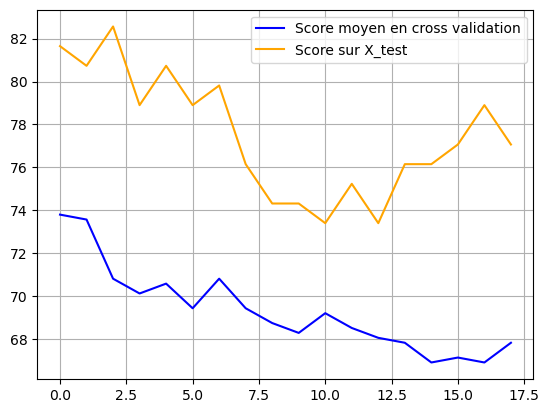

In [628]:
plt.plot(scores_array, color="blue", label="Score moyen en cross validation")
plt.plot(test_scores, color="orange", label="Score sur X_test")
plt.grid(True)
plt.legend()

#### Prédiction sur le test_set

In [1362]:
test_prediction_knn = classifieur(X_test, X_train, Y_train, 3)
test_prediction_knn

['C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C4',
 'C2',
 'C2',
 'C1',
 'C1',
 'C3',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C3',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2']

### Accuracy

In [1365]:
are(test_prediction_knn, Y_test)

82.56881

#### Matrice de Confusion

In [1368]:
def matrice_confusion(prediction, reality):
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y ("reality").
    stack_predict_et_y = np.vstack((prediction, reality["classification_diagnostic"])).T
    classes_y = np.unique(reality)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    return confusion_matrix

matrice_confusion(test_prediction_knn, Y_test)

array([[36,  4,  0,  0,  0],
       [ 7, 52,  0,  0,  0],
       [ 3,  2,  2,  1,  0],
       [ 0,  1,  0,  0,  0],
       [ 1,  0,  0,  0,  0]])

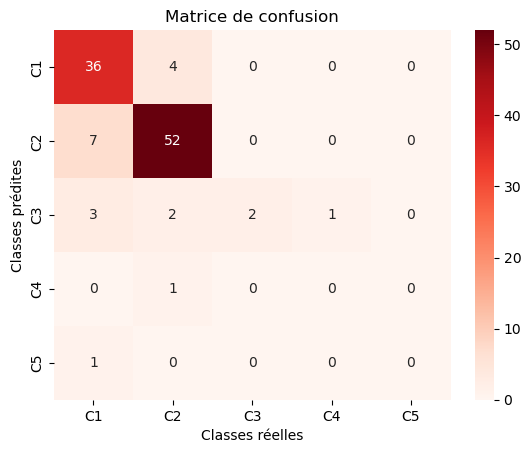

In [1370]:
sns.heatmap(matrice_confusion(test_prediction_knn, Y_test), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

### Prédiction du dataset "prev"

In [1373]:
previsions_prev_data = classifieur(prev_encode, X_train, Y_train, 5)
previsions_prev_data

['C2',
 'C2',
 'C2',
 'C1',
 'C4',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C4',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C3',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C4',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C2',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C1',
 'C1',
 'C2',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C1',
 'C2',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2',
 'C1',
 'C2']

In [1375]:
pd.DataFrame(previsions_prev_data).value_counts()
# On peut voir les proportions de chaque classe de notre tableau de prédictions.

0 
C1    69
C2    64
C4     3
C3     1
Name: count, dtype: int64

# Arbre de décision

In [1378]:
x2 = arbres[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()
x2["esperance_maintien"] = x2["esperance_maintien"].astype(str)
y = arbres[["classification_diagnostic"]]

prev2 = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]].copy()
prev2["esperance_maintien"] = prev2["esperance_maintien"].astype(str)

### Division en X_train, X_test, Y_train, Y_test

In [1381]:
from sklearn.model_selection import train_test_split

In [1383]:
X_train, X_test, Y_train, Y_test = train_test_split(x2, y, test_size=0.10, random_state=42)

### Arbre de décision - En programmation orientée objet

In [1386]:
class Node:

    def __init__(self, feature, value, cost, left_node, right_node, depth, pop, prediction=None):
        self.feature = feature # Un noeud contient une feature et une valeur pour split notre dataset
        self.value = value
        self.left_node = left_node # Il contient également une branche gauche...
        self.right_node = right_node #... et droite, appelée ici "node"
        self.cost = cost # le cout de la séparation calculé avec l'indice Gini
        self.depth = depth # Profondeur de l'arbre
        self.pop = pop # Taille de l'echantillon du noeud
        self.prediction = prediction #La classe majoritaire du noeud 


class decision_tree_classifier :

    def __init__(self, max_depth, seuil, min_samples_split, min_impurity_decrease):
        self.max_depth = max_depth #La profondeur maximale
        self.seuil = seuil #Le seuil de score Gini minimal pour split notre dataset
        self.min_samples_split = min_samples_split
        self.min_impurity_decrease = min_impurity_decrease

    def _split(self, feature, value, dataset):
        left = dataset[dataset[feature] == value]
        right = dataset[dataset[feature] != value]
        return left, right

    def _gini(self, y):
        # Calcul de l'impureté de Gini pour un noeud
        occurences = y.value_counts().to_numpy()
        population = np.sum(occurences)
        proportions = occurences/population
        if (population == 0):
            return 0;
        return 1 - np.sum(proportions**2)

    def _best_split(self, X, y):
        # Recherche la meilleure combinaison (feature, valeur) pour diviser le dataset avec un coût (impureté) minimal
        
        best_feature = X.columns[0]
        best_value = np.unique(X[X.columns[0]])[0] #On initialise la best feature comme étant la 1ère colonne
        best_cost = 1 # Score initialisé au plus bas : 1
        
        for feature in X.columns:
            for value in X[feature].unique():

                idx_left = X[feature] == value
                y_left = y[idx_left]
                y_right = y[~idx_left]
                
                # On évite une division par zéro :
                if len(y_left) == 0 or len(y_right) == 0:
                    continue

                cost = (len(y_left) * self._gini(y_left) + len(y_right) * self._gini(y_right))/len(y)
                # On calcule le critère de Gini pour cette découpe et on la sauvegarde ou non en fonction de son score
                if cost < best_cost:
                    # Si le couple (feature + valeur) possède le coût le plus faible, alors on le sauvegarde.
                    best_cost = cost
                    best_value = value
                    best_feature = feature
        return best_feature, best_value, best_cost



    def fit(self, X=None, y=None, depth=0):
        # Condition d'arrêt de la récursion :
        
        # 1/ Si le nombre d'exemples est inférieur à min_samples_split, arrêter
        if self.min_samples_split is not None and len(y) < self.min_samples_split:
            mode_values = y.mode()
            prediction = mode_values.iloc[0] if not mode_values.empty else None
            return Node(None, None, 0, None, None, depth, len(y), prediction=prediction)
        
        # 2/ Profondeur maximale ou impureté suffisamment faible.
        if depth > self.max_depth or self._gini(y) <= self.seuil:
            # Si y est vide ou on a atteint un état terminal, on retourne un noeud terminal
            if y.empty:
                return Node(None, None, 0, None, None, depth, 0, prediction=None)
            else:
                prediction = y.mode().iloc[0]
                return Node(None, None, 0, None, None, depth, len(y), prediction=prediction)
        
        # Recherche du meilleur split
        best_feature, best_value, best_cost = self._best_split(X, y) #On cherche la meilleure (feature + value) pour split
        if best_feature is None:
            prediction = y.mode().iloc[0]  # Classe majoritaire
            return Node(feature=None, value=None, cost=0, left_node=None, right_node=None, depth=depth, pop=len(y), prediction=prediction)

        # 3/ On fait la soustraction entre l'indice gini d'un noeud (avant sa division) et l'indice de gini global après la division en fonction de la variable au meilleur score.
        # Si cette soustraction est au dessus d'un certains seuil, alors le split est jugé inutile et on crée un noeud terminal.
        # Sinon on continue à prolonger l'arbre.
        if self.min_impurity_decrease != None:
            parent_impurity = self._gini(y)
            if parent_impurity - best_cost < self.min_impurity_decrease:
                if y.empty:
                    return Node(None, None, 0, None, None, depth, 0, prediction=None)
                prediction = y.mode().iloc[0]
                return Node(None, None, 0, None, None, depth, len(y), prediction=prediction)
        
        # On découpe selon l'index:
        idx_left = X[best_feature] == best_value
        X_left, y_left = X[idx_left], y[idx_left] 
        X_right, y_right = X[~idx_left], y[~idx_left]

        left_node = self.fit(X_left, y_left, depth + 1)
        right_node = self.fit(X_right, y_right, depth + 1)        

        #A chaque tour de fonction, on retourne un noeud contenant les 2 noeuds/branches suivants, et des informations sur le noeud actuel.
        return Node(feature=best_feature, value=best_value, cost=best_cost, left_node=left_node, right_node=right_node, depth=depth, pop=len(y), prediction=None)

    
    def predict_ligne(self, ligne, node=None):
        # predict() prend une ligne de dataset à la fois ("ligne") ainsi que la racine de l'arbre qu'on va parcourir pour prédire nos données.
        # Si notre noeud a pour paramètre feature = None, alors c'est qu'on fait face à un noeud terminal / feuille

        if node.feature is None:
            return node.prediction # Ici on retourne alors la classe majoritaire du noeud.
        if ligne[node.feature] == node.value:
            return self.predict_ligne(ligne, node.left_node)
        else:
            return self.predict_ligne(ligne, node.right_node)

    def predict(self, X, root):
        # On prédit prédit les classes pour l'ensemble du DataFrame X. (Histoire de ne pas refaire de boucle sur chaque ligne du dataset à prédire)
        return pd.DataFrame(X.apply(lambda ligne: self.predict_ligne(ligne, node=root), axis=1), columns=[y.columns[0]])

### Entraînement modèle

In [1389]:
tree = decision_tree_classifier(
    max_depth=10, 
    seuil=0.1, 
    min_samples_split = 5, # On peut mettre la valeur None
    min_impurity_decrease = 0.01 # On peut mettre la valeur None
)
root = tree.fit(X_train, Y_train) 

### Recherches des paramètres

In [1236]:
from sklearn.model_selection import StratifiedKFold
from joblib import Parallel, delayed

## 🛑ATTENTION✋ : 
## La fonction ci-dessous utilise tous les coeurs de votre processeur pour s'éxecuter 👇
#### La fonction cherche tous les paramètres optimaux pour notre arbres de classification, tout en faisant une cross validation avec StratifiedKFold. 
#### Elle prend environ entre 2 à 7 minutes pour trouver les paramètres optimaux (temps variable en fonction du processeur) et utilise 100% du processeur grâce à la librairie joblib, importé juste au dessus. Cela permet d'accélérer la recherche des meilleurs hyperparamètres.
#### N'exécutez la cellule ci-dessous que si vous avez un processeur assez-rapide et de la patience pour attendre 5 longues minutes. Sinon c'est inutile 😀


In [ ]:
######### Recherche des paramètres #########

depths_array = [5, 10, 15, 20]
gini_array = [0.10, 0.20, 0.30]
min_samples_split_array = [2, 5, 10]
min_impurity_decrease_array = [0.0, 0.01, 0.02]

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

def best_params(depth, seuil, min_samples_split, min_impurity_decrease, folds, X, y):
    scores = []
    #On crée les indices liés aux folds du sous-train set et du val set grâce à StratifiedKFold
    for train_index, test_index in folds.split(X, y): 
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]
        
        tree = decision_tree_classifier(max_depth=depth, 
                                        seuil=seuil, 
                                        min_samples_split=min_samples_split,
                                        min_impurity_decrease=min_impurity_decrease
                                       )
        root = tree.fit(X_train, Y_train)
        predictions = tree.predict(X_test, root=root)
        scores.append(are(predictions, Y_test))
    mean_score = np.mean(scores)
    return {
        "depth": depth,
        "seuil": seuil,
        "min_samples_split": min_samples_split,
        "min_impurity_decrease": min_impurity_decrease,
        "mean_score": mean_score
    }


# On distribue les tâches aux différents coeurs du processeurs pour accélérer la recherche des meilleurs paramètres.
resultats = Parallel(n_jobs=-1)(
    delayed(best_params)(depth, seuil, mss, mid, skf, x2, y)
    for depth in depths_array
    for seuil in gini_array
    for mss in min_samples_split_array
    for mid in min_impurity_decrease_array
)

results_df = pd.DataFrame(resultats)
results_df.sort_values(by="mean_score", ascending=False)

### Prédiction sur X_test

In [1391]:
test_predict = tree.predict(X_test, root)
test_predict.head()

,classification_diagnostic
ID_ARBRE,
468,C2
262,C1
365,C2
547,C1
557,C2


In [1393]:
test_predict.value_counts()

classification_diagnostic
C1                           25
C2                           25
C3                            4
C4                            1
Name: count, dtype: int64

In [1395]:
def are(predict, Y):
    correct = np.sum(np.array(predict).flatten() == Y.to_numpy().flatten())
    taux = np.round((correct / len(Y)) * 100, 5)  # Pourcentage de bonnes prédictions
    return taux

In [1397]:
are(test_predict, Y_test)

87.27273

#### Matrice de Confusion

In [1400]:
def matrice_confusion(prediction, reality):
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y ("reality").
    stack_predict_et_y = np.vstack((prediction, reality["classification_diagnostic"])).T
    classes_y = np.unique(reality)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    return confusion_matrix

matrice_confusion(test_predict["classification_diagnostic"], Y_test)

array([[23,  2,  0,  0,  0],
       [ 2, 22,  0,  0,  0],
       [ 0,  1,  2,  0,  0],
       [ 0,  0,  1,  1,  0],
       [ 0,  0,  1,  0,  0]])

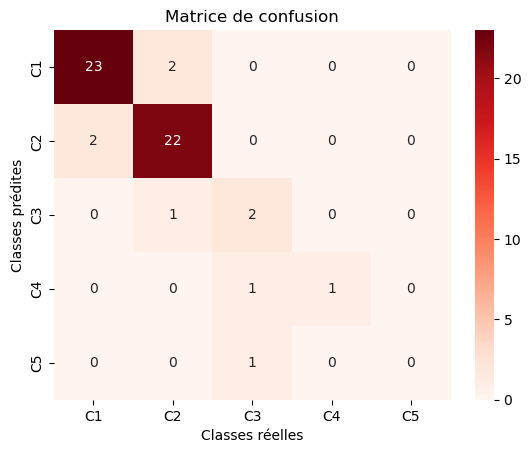

In [1402]:
sns.heatmap(matrice_confusion(test_predict["classification_diagnostic"], Y_test), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

#### Score en fonction de la profondeur

In [913]:
scores_depths = []
for depth in range(3, 20):
    tree2 = decision_tree_classifier(
        max_depth=depth, 
        seuil=0.2, 
        min_samples_split = None, # On peut mettre la valeur None
        min_impurity_decrease = None # On peut mettre la valeur None
    )
    root2 = tree2.fit(X_train, Y_train) 
    predict_temp = tree2.predict(X_test, root=root2)
    scores_depths.append(are(predict_temp, Y_test))
    

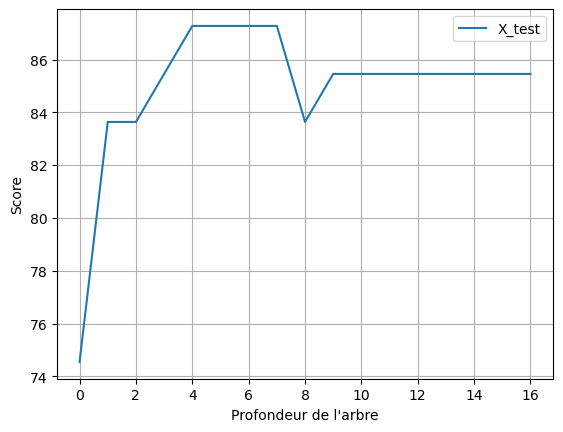

In [914]:
plt.plot(scores_depths, label="X_test")
plt.xlabel("Profondeur de l'arbre")  # Nom de l'axe des abscisses
plt.ylabel("Score")   
plt.grid(True)
plt.legend()

### Prédictions sur Prev

In [271]:
prev_predictions = tree.predict(prev2, root=root)
prev_predictions

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3
...,...
694,C2
695,C3
696,C2


In [273]:
prev_predictions.value_counts()

classification_diagnostic
C2                           72
C1                           58
C3                            6
C5                            1
Name: count, dtype: int64

### Enregistrement du ficher au format .csv

In [ ]:
prev_predictions.to_csv("prev_arbre_decision.csv")